In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

uploaded = files.upload()

Saving Aviation_Aircraft_Utilisation_Dataset.csv to Aviation_Aircraft_Utilisation_Dataset.csv


In [4]:
df = pd.read_csv("Aviation_Aircraft_Utilisation_Dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (300, 8)


,Flight_ID,Aircraft_Type,Route,Flight_Duration,Turnaround_Time,Route_Distance,Passenger_Capacity,Actual_Passengers
0,FL1001,Airbus A321,Chennai-Delhi,206,48,1760,220,179
1,FL1002,Airbus A321,Chennai-Bengaluru,45,32,290,220,162
2,FL1003,Boeing 737-800,Bengaluru-Hyderabad,56,50,500,174,126
3,FL1004,Airbus A320,Kolkata-Mumbai,182,56,1660,180,159
4,FL1005,Airbus A321,Kolkata-Mumbai,200,73,1660,220,168


In [5]:
# Check missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Flight_ID             0
Aircraft_Type         0
Route                 0
Flight_Duration       0
Turnaround_Time       0
Route_Distance        0
Passenger_Capacity    0
Actual_Passengers     0
dtype: int64


In [6]:
# Check duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [7]:
# Check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Flight_ID           300 non-null    object
 1   Aircraft_Type       300 non-null    object
 2   Route               300 non-null    object
 3   Flight_Duration     300 non-null    int64 
 4   Turnaround_Time     300 non-null    int64 
 5   Route_Distance      300 non-null    int64 
 6   Passenger_Capacity  300 non-null    int64 
 7   Actual_Passengers   300 non-null    int64 
dtypes: int64(5), object(3)
memory usage: 18.9+ KB


In [8]:
numeric_columns = [
    'Flight_Duration',
    'Turnaround_Time',
    'Route_Distance',
    'Passenger_Capacity',
    'Actual_Passengers'
]

for col in numeric_columns:
    print(col, "negative values:", (df[col] < 0).sum())

Flight_Duration negative values: 0
Turnaround_Time negative values: 0
Route_Distance negative values: 0
Passenger_Capacity negative values: 0
Actual_Passengers negative values: 0


In [9]:
invalid_passengers = df[
    df['Actual_Passengers'] > df['Passenger_Capacity']
]

print("Flights where passengers exceed capacity:",
      len(invalid_passengers))

invalid_passengers.head()

Flights where passengers exceed capacity: 0


,Flight_ID,Aircraft_Type,Route,Flight_Duration,Turnaround_Time,Route_Distance,Passenger_Capacity,Actual_Passengers


In [10]:
print("Final dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Final dataset shape: (300, 8)

Columns:
['Flight_ID', 'Aircraft_Type', 'Route', 'Flight_Duration', 'Turnaround_Time', 'Route_Distance', 'Passenger_Capacity', 'Actual_Passengers']


In [11]:
# Descriptive statistics for numerical columns
df.describe()

,Flight_Duration,Turnaround_Time,Route_Distance,Passenger_Capacity,Actual_Passengers
count,300.000000,300.00000,300.000000,300.000000,300.000000
mean,135.796667,51.56000,1097.800000,188.360000,147.873333
std,59.049681,13.07707,500.564056,18.913031,26.192954
min,45.000000,30.00000,290.000000,174.000000,82.000000
25%,86.750000,40.00000,755.000000,174.000000,129.000000
50%,143.000000,52.00000,1150.000000,180.000000,147.000000
75%,196.000000,62.25000,1660.000000,220.000000,165.000000
max,239.000000,75.00000,1760.000000,220.000000,216.000000


In [12]:
print("Aircraft Types:")
print(df['Aircraft_Type'].value_counts())

Aircraft Types:
Aircraft_Type
Boeing 737-800    79
Airbus A321       78
Airbus A320       74
Boeing 737 MAX    69
Name: count, dtype: int64


In [13]:
print("Number of unique routes:", df['Route'].nunique())

print("\nFlights by route:")
print(df['Route'].value_counts())

Number of unique routes: 10

Flights by route:
Route
Chennai-Bengaluru      41
Bengaluru-Hyderabad    34
Chennai-Mumbai         34
Kolkata-Mumbai         33
Delhi-Bengaluru        28
Hyderabad-Delhi        28
Mumbai-Bengaluru       28
Mumbai-Delhi           26
Delhi-Kolkata          25
Chennai-Delhi          23
Name: count, dtype: int64


In [14]:
print("Average Flight Duration:",
      df['Flight_Duration'].mean())

print("Average Turnaround Time:",
      df['Turnaround_Time'].mean())

print("Average Route Distance:",
      df['Route_Distance'].mean())

print("Average Passenger Capacity:",
      df['Passenger_Capacity'].mean())

print("Average Actual Passengers:",
      df['Actual_Passengers'].mean())

Average Flight Duration: 135.79666666666665
Average Turnaround Time: 51.56
Average Route Distance: 1097.8
Average Passenger Capacity: 188.36
Average Actual Passengers: 147.87333333333333


In [15]:
df['Passenger_Load_Factor'] = (
    df['Actual_Passengers'] /
    df['Passenger_Capacity']
) * 100

df[['Flight_ID',
    'Aircraft_Type',
    'Route',
    'Passenger_Capacity',
    'Actual_Passengers',
    'Passenger_Load_Factor']].head(10)

,Flight_ID,Aircraft_Type,Route,Passenger_Capacity,Actual_Passengers,Passenger_Load_Factor
0,FL1001,Airbus A321,Chennai-Delhi,220,179,81.363636
1,FL1002,Airbus A321,Chennai-Bengaluru,220,162,73.636364
2,FL1003,Boeing 737-800,Bengaluru-Hyderabad,174,126,72.413793
3,FL1004,Airbus A320,Kolkata-Mumbai,180,159,88.333333
4,FL1005,Airbus A321,Kolkata-Mumbai,220,168,76.363636
5,FL1006,Airbus A321,Chennai-Delhi,220,174,79.090909
6,FL1007,Airbus A320,Hyderabad-Delhi,180,135,75.000000
7,FL1008,Boeing 737 MAX,Delhi-Kolkata,178,146,82.022472
8,FL1009,Boeing 737-800,Chennai-Mumbai,174,112,64.367816
9,FL1010,Boeing 737-800,Mumbai-Bengaluru,174,109,62.643678


In [16]:
average_load_factor = df['Passenger_Load_Factor'].mean()

print("Average Passenger Load Factor:",
      round(average_load_factor, 2), "%")

Average Passenger Load Factor: 78.48 %


In [17]:
low_occupancy = df[df['Passenger_Load_Factor'] < 70]

print("Number of low-occupancy flights:",
      len(low_occupancy))

low_occupancy[['Flight_ID',
               'Aircraft_Type',
               'Route',
               'Passenger_Load_Factor']].head(20)

Number of low-occupancy flights: 64


,Flight_ID,Aircraft_Type,Route,Passenger_Load_Factor
8,FL1009,Boeing 737-800,Chennai-Mumbai,64.367816
9,FL1010,Boeing 737-800,Mumbai-Bengaluru,62.643678
22,FL1023,Airbus A321,Delhi-Kolkata,66.818182
23,FL1024,Boeing 737-800,Bengaluru-Hyderabad,61.494253
35,FL1036,Boeing 737-800,Mumbai-Bengaluru,65.517241
41,FL1042,Boeing 737-800,Chennai-Bengaluru,68.390805
48,FL1049,Boeing 737 MAX,Hyderabad-Delhi,64.606742
53,FL1054,Airbus A321,Delhi-Bengaluru,63.181818
57,FL1058,Boeing 737 MAX,Bengaluru-Hyderabad,69.101124
59,FL1060,Boeing 737 MAX,Chennai-Bengaluru,66.292135


In [18]:
low_occupancy = df[df['Passenger_Load_Factor'] < 70]

print("Number of low-occupancy flights:",
      len(low_occupancy))

low_occupancy[['Flight_ID',
               'Aircraft_Type',
               'Route',
               'Passenger_Load_Factor']].head(20)

Number of low-occupancy flights: 64


,Flight_ID,Aircraft_Type,Route,Passenger_Load_Factor
8,FL1009,Boeing 737-800,Chennai-Mumbai,64.367816
9,FL1010,Boeing 737-800,Mumbai-Bengaluru,62.643678
22,FL1023,Airbus A321,Delhi-Kolkata,66.818182
23,FL1024,Boeing 737-800,Bengaluru-Hyderabad,61.494253
35,FL1036,Boeing 737-800,Mumbai-Bengaluru,65.517241
41,FL1042,Boeing 737-800,Chennai-Bengaluru,68.390805
48,FL1049,Boeing 737 MAX,Hyderabad-Delhi,64.606742
53,FL1054,Airbus A321,Delhi-Bengaluru,63.181818
57,FL1058,Boeing 737 MAX,Bengaluru-Hyderabad,69.101124
59,FL1060,Boeing 737 MAX,Chennai-Bengaluru,66.292135


In [19]:
aircraft_summary = df.groupby('Aircraft_Type').agg({
    'Flight_Duration': 'mean',
    'Turnaround_Time': 'mean',
    'Route_Distance': 'mean',
    'Passenger_Capacity': 'mean',
    'Actual_Passengers': 'mean',
    'Passenger_Load_Factor': 'mean'
}).round(2)

aircraft_summary

,Flight_Duration,Turnaround_Time,Route_Distance,Passenger_Capacity,Actual_Passengers,Passenger_Load_Factor
Aircraft_Type,,,,,,
Airbus A320,128.99,52.84,1038.78,180.0,138.97,77.21
Airbus A321,146.40,50.55,1190.51,220.0,173.62,78.92
Boeing 737 MAX,132.61,49.30,1072.61,178.0,141.22,79.34
Boeing 737-800,134.49,53.33,1083.54,174.0,136.61,78.51


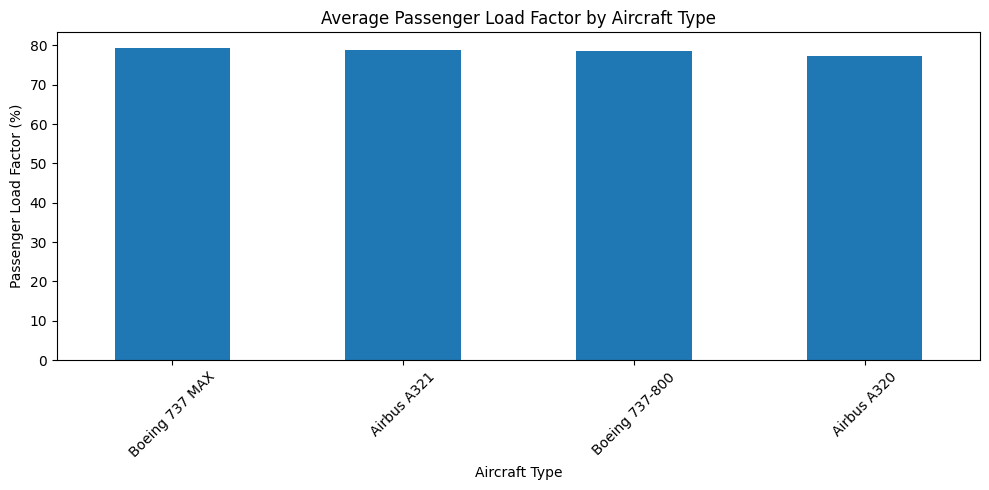

In [20]:
import matplotlib.pyplot as plt

aircraft_load = df.groupby('Aircraft_Type')['Passenger_Load_Factor'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
aircraft_load.plot(kind='bar')

plt.title('Average Passenger Load Factor by Aircraft Type')
plt.xlabel('Aircraft Type')
plt.ylabel('Passenger Load Factor (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
route_load = df.groupby('Route')['Passenger_Load_Factor'].mean().sort_values()

print(route_load)

Route
Delhi-Kolkata          75.356306
Delhi-Bengaluru        75.550251
Chennai-Mumbai         77.054958
Bengaluru-Hyderabad    77.409821
Hyderabad-Delhi        79.034028
Chennai-Delhi          79.052483
Kolkata-Mumbai         79.987019
Mumbai-Delhi           80.129856
Mumbai-Bengaluru       80.248939
Chennai-Bengaluru      80.318264
Name: Passenger_Load_Factor, dtype: float64


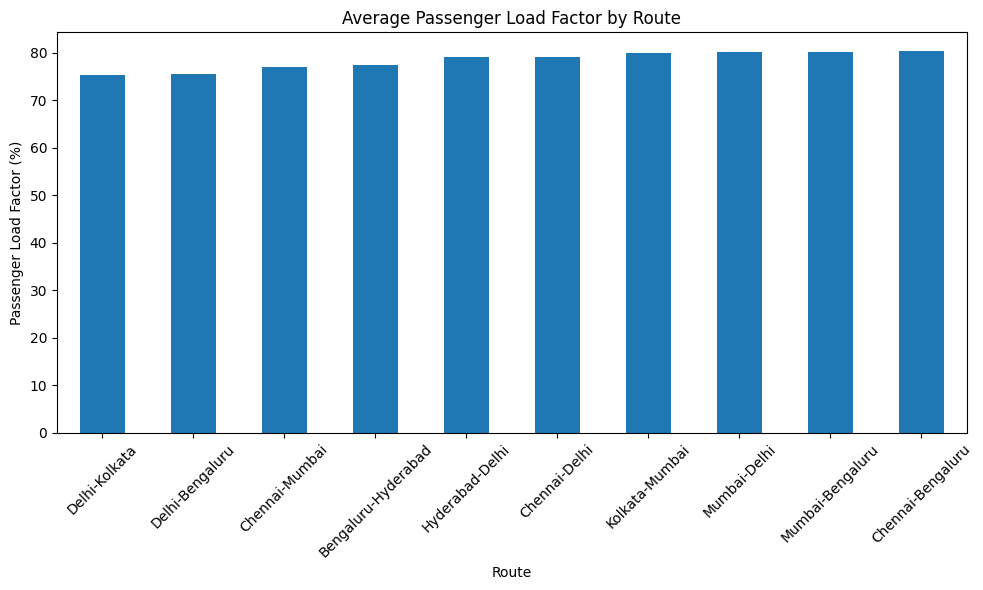

In [22]:
plt.figure(figsize=(10,6))
route_load.plot(kind='bar')

plt.title('Average Passenger Load Factor by Route')
plt.xlabel('Route')
plt.ylabel('Passenger Load Factor (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

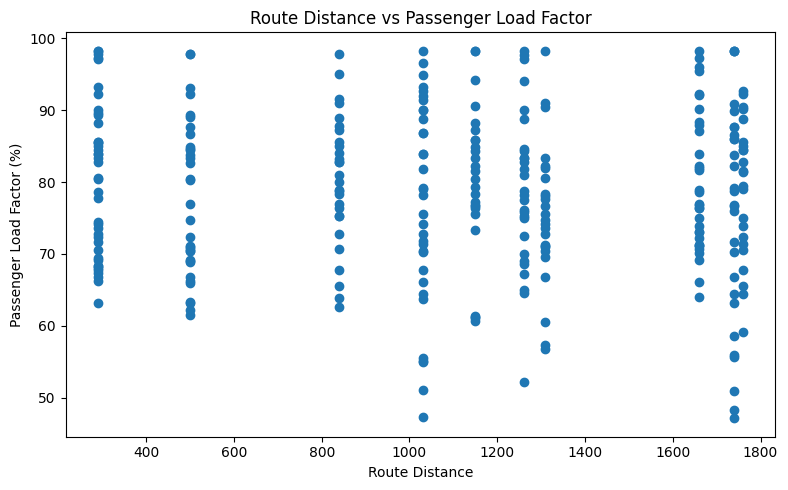

In [23]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['Route_Distance'],
    df['Passenger_Load_Factor']
)

plt.title('Route Distance vs Passenger Load Factor')
plt.xlabel('Route Distance')
plt.ylabel('Passenger Load Factor (%)')

plt.tight_layout()
plt.show()

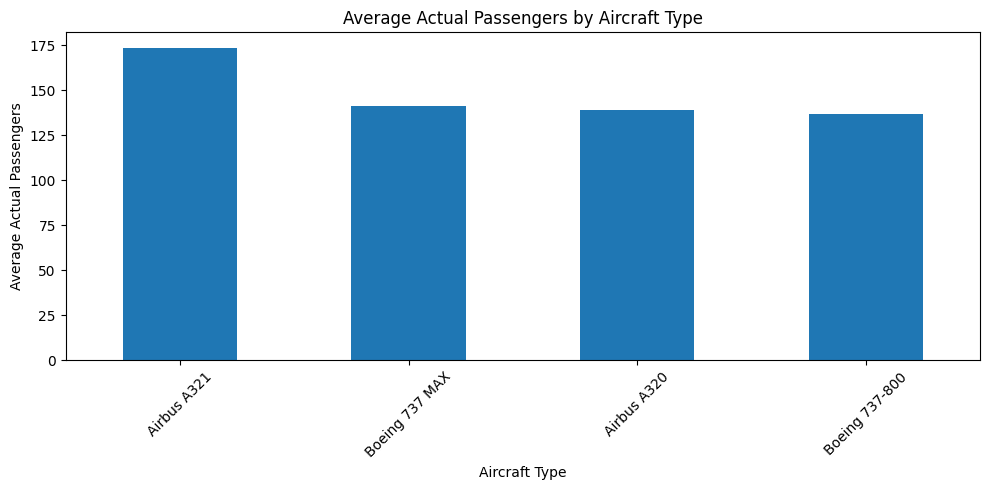

In [24]:
aircraft_passengers = df.groupby('Aircraft_Type')['Actual_Passengers'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))

aircraft_passengers.plot(kind='bar')

plt.title('Average Actual Passengers by Aircraft Type')
plt.xlabel('Aircraft Type')
plt.ylabel('Average Actual Passengers')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
route_aircraft = df.groupby(
    ['Route', 'Aircraft_Type']
).agg({
    'Passenger_Load_Factor': 'mean',
    'Actual_Passengers': 'mean',
    'Passenger_Capacity': 'mean',
    'Route_Distance': 'mean'
}).round(2)

route_aircraft = route_aircraft.sort_values(
    'Passenger_Load_Factor'
)

route_aircraft.head(10)

Passenger_Load_Factor  Actual_Passengers  \
Route               Aircraft_Type                                              
Delhi-Bengaluru     Airbus A320                     65.28             117.50   
                    Boeing 737-800                  70.69             123.00   
Hyderabad-Delhi     Airbus A320                     71.53             128.75   
Bengaluru-Hyderabad Airbus A320                     72.59             130.67   
Mumbai-Delhi        Boeing 737 MAX                  72.75             129.50   
Delhi-Kolkata       Boeing 737 MAX                  73.03             130.00   
Hyderabad-Delhi     Boeing 737 MAX                  73.31             130.50   
Delhi-Kolkata       Airbus A321                     74.27             163.40   
Chennai-Mumbai      Airbus A321                     74.34             163.55   
Bengaluru-Hyderabad Airbus A321                     74.70             164.33   

                                    Passenger_Capacity  Route_Distance  
Route               Aircraft_Type                                       
Delhi-Bengaluru     Airbus A320                  180.0          1740.0  
                    Boeing 737-800               174.0          1740.0  
Hyderabad-Delhi     Airbus A320                  180.0          1260.0  
Bengaluru-Hyderabad Airbus A320                  180.0           500.0  
Mumbai-Delhi        Boeing 737 MAX               178.0          1150.0  
Delhi-Kolkata       Boeing 737 MAX               178.0          1310.0  
Hyderabad-Delhi     Boeing 737 MAX               178.0          1260.0  
Delhi-Kolkata       Airbus A321                  220.0          1310.0  
Chennai-Mumbai      Airbus A321                  220.0          1030.0  
Bengaluru-Hyderabad Airbus A321                  220.0           500.0

In [26]:
correlation = df[
    ['Route_Distance', 'Passenger_Load_Factor']
].corr()

print(correlation)

                       Route_Distance  Passenger_Load_Factor
Route_Distance               1.000000              -0.045519
Passenger_Load_Factor       -0.045519               1.000000


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = df[
    [
        'Flight_Duration',
        'Turnaround_Time',
        'Route_Distance',
        'Passenger_Capacity'
    ]
]

y = df['Passenger_Load_Factor']

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (240, 4)
Testing data: (60, 4)


In [29]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [30]:
y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print(y_pred[:10])

Predictions generated successfully!
[81.42765779 80.22873679 80.04122735 78.72339405 77.61665617 79.08165932
 79.05551673 78.88654118 78.44053567 78.86742929]


In [31]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 4))

MAE : 8.77
RMSE: 10.46
R²  : -0.0386


In [32]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients

,Feature,Coefficient
0,Flight_Duration,-0.157718
1,Turnaround_Time,0.005532
2,Route_Distance,0.016961
3,Passenger_Capacity,0.017280


In [33]:
print("Average Passenger Load Factor:",
      round(df['Passenger_Load_Factor'].mean(), 2), "%")

print("\nLowest Load Factor Routes:")
print(route_load.head(5))

print("\nAircraft Load Factor:")
print(aircraft_load)

print("\nLowest Route-Aircraft Combinations:")
print(route_aircraft.head(10))

print("\nRoute Distance vs Load Factor Correlation:")
print(round(df['Route_Distance'].corr(df['Passenger_Load_Factor']), 4))

Average Passenger Load Factor: 78.48 %

Lowest Load Factor Routes:
Route
Delhi-Kolkata          75.356306
Delhi-Bengaluru        75.550251
Chennai-Mumbai         77.054958
Bengaluru-Hyderabad    77.409821
Hyderabad-Delhi        79.034028
Name: Passenger_Load_Factor, dtype: float64

Aircraft Load Factor:
Aircraft_Type
Boeing 737 MAX    79.335613
Airbus A321       78.916084
Boeing 737-800    78.510112
Airbus A320       77.207207
Name: Passenger_Load_Factor, dtype: float64

Lowest Route-Aircraft Combinations:
                                    Passenger_Load_Factor  Actual_Passengers  \
Route               Aircraft_Type                                              
Delhi-Bengaluru     Airbus A320                     65.28             117.50   
                    Boeing 737-800                  70.69             123.00   
Hyderabad-Delhi     Airbus A320                     71.53             128.75   
Bengaluru-Hyderabad Airbus A320                     72.59             130.67   
Mumbai-D